In [2]:
import pandas as pd

# Load the dataset
df = pd.read_csv('data.csv')

# Check for missing values
missing_data = df.isnull().sum()

# Print missing data summary
print("Missing Data Summary:")
print(missing_data) # Identify if there are missing values

# Handling Missing Data:
# For numerical columns, fill with appropriate values (mean, median, mode)
# Decide how to handle missing data for each column (e.g., fill with appropriate values, drop rows, etc.).
df['Engine HP'] = df['Engine HP'].fillna(df['Engine HP'].median())
df['Engine Cylinders'] = df['Engine Cylinders'].fillna(df['Engine Cylinders'].mean())

# For categorical columns, drop rows with missing values
df = df.dropna(subset=['Engine Fuel Type'])

Missing Data Summary:
Make                    0
Model                   0
Year                    0
Engine Fuel Type        3
Engine HP              69
Engine Cylinders       30
Transmission Type       0
Driven_Wheels           0
Number of Doors         6
Market Category      3742
Vehicle Size            0
Vehicle Style           0
highway MPG             0
city mpg                0
Popularity              0
MSRP                    0
dtype: int64


Summary of Data Cleaning

Missing Value Identification: We checked each column in the dataset to identify which contain missing data.

Handling Missing Data:
For numerical columns (Engine HP and Engine Cylinders), we filled NaN values with the median/mean.
For categorical columns (Engine Fuel Type), we dropped rows where this column contained missing values.

This step is crucial for ensuring that our machine learning models are trained on a complete dataset, which can lead to better model performance and more accurate predictions.

In [3]:
# Convert specific columns to appropriate data types
# Ensure that columns are of the correct data type for analysis (e.g., ensure that 'Year' is an integer).
df['Year'] = df['Year'].astype(int)

# Verify the data types after conversion
print("Data Types After Conversion:")
print(df.dtypes)

Data Types After Conversion:
Make                     str
Model                    str
Year                   int64
Engine Fuel Type         str
Engine HP            float64
Engine Cylinders     float64
Transmission Type        str
Driven_Wheels            str
Number of Doors      float64
Market Category          str
Vehicle Size             str
Vehicle Style            str
highway MPG            int64
city mpg               int64
Popularity             int64
MSRP                   int64
dtype: object


Summary of Data Type Conversion

Conversion:
The 'Year' column was converted from a string to an integer using astype(int).

Verification:
We checked the data type of each column using dtypes after the conversion.

This ensures that the data is in a format suitable for machine learning algorithms, facilitating more accurate analysis and predictions.

In [4]:
# Filter the dataset to include only cars from the year 1995 and later
filtered_df = df[df['Year'] >= 1995]

print("Filtered Data:")
print(filtered_df)

Filtered Data:
          Make       Model  Year                Engine Fuel Type  Engine HP  \
0          BMW  1 Series M  2011     premium unleaded (required)      335.0   
1          BMW    1 Series  2011     premium unleaded (required)      300.0   
2          BMW    1 Series  2011     premium unleaded (required)      300.0   
3          BMW    1 Series  2011     premium unleaded (required)      230.0   
4          BMW    1 Series  2011     premium unleaded (required)      230.0   
...        ...         ...   ...                             ...        ...   
11909    Acura         ZDX  2012     premium unleaded (required)      300.0   
11910    Acura         ZDX  2012     premium unleaded (required)      300.0   
11911    Acura         ZDX  2012     premium unleaded (required)      300.0   
11912    Acura         ZDX  2013  premium unleaded (recommended)      300.0   
11913  Lincoln      Zephyr  2006                regular unleaded      221.0   

       Engine Cylinders Transmission

Summary of Data Filtering

Filtering:
We used boolean indexing to select rows where the 'Year' column values are greater than or equal to 1995.

Verification:
The filtered dataset contains only cars that meet the specified criteria.

This step is useful for focusing on a specific period of interest, allowing for further analysis and insights based on time-series data.

In [5]:
# Convert the 'Vehicle Style' and 'Market Category' columns to lowercase
# Use .fillna('') to handle NaN values in Market Category before lowercasing
df['Vehicle Style'] = df['Vehicle Style'].str.lower()
df['Market Category'] = df['Market Category'].fillna('').str.lower()

print("DataFrame after String Operations:")
print(df)

DataFrame after String Operations:
          Make       Model  Year                Engine Fuel Type  Engine HP  \
0          BMW  1 Series M  2011     premium unleaded (required)      335.0   
1          BMW    1 Series  2011     premium unleaded (required)      300.0   
2          BMW    1 Series  2011     premium unleaded (required)      300.0   
3          BMW    1 Series  2011     premium unleaded (required)      230.0   
4          BMW    1 Series  2011     premium unleaded (required)      230.0   
...        ...         ...   ...                             ...        ...   
11909    Acura         ZDX  2012     premium unleaded (required)      300.0   
11910    Acura         ZDX  2012     premium unleaded (required)      300.0   
11911    Acura         ZDX  2012     premium unleaded (required)      300.0   
11912    Acura         ZDX  2013  premium unleaded (recommended)      300.0   
11913  Lincoln      Zephyr  2006                regular unleaded      221.0   

       Engine Cy

Summary of String Operations

String Operations:
The 'Vehicle Style' and 'Market Category' columns were converted to lowercase using str.lower().

Verification:
We checked the data types of each column after the string operations to ensure that all text fields are now in lower case.

This step is important for consistency and simplifies the processing of text data for further analysis.

In [6]:
# Create a new column for Total MPG = average of city mpg and highway MPG.
df['Total MPG'] = df['city mpg'] + df['highway MPG']

# Calculate Price per HP
df['Price per HP'] = df['MSRP'] / df['Engine HP']

print("DataFrame after Feature Engineering:")
print(df)

# Calculate summary statistics (mean, median, standard deviation) for the following columns:
#    Engine HP, MSRP, Popularity, highway MPG, and city mpg.

DataFrame after Feature Engineering:
          Make       Model  Year                Engine Fuel Type  Engine HP  \
0          BMW  1 Series M  2011     premium unleaded (required)      335.0   
1          BMW    1 Series  2011     premium unleaded (required)      300.0   
2          BMW    1 Series  2011     premium unleaded (required)      300.0   
3          BMW    1 Series  2011     premium unleaded (required)      230.0   
4          BMW    1 Series  2011     premium unleaded (required)      230.0   
...        ...         ...   ...                             ...        ...   
11909    Acura         ZDX  2012     premium unleaded (required)      300.0   
11910    Acura         ZDX  2012     premium unleaded (required)      300.0   
11911    Acura         ZDX  2012     premium unleaded (required)      300.0   
11912    Acura         ZDX  2013  premium unleaded (recommended)      300.0   
11913  Lincoln      Zephyr  2006                regular unleaded      221.0   

       Engine 

Summary of Feature Engineering

New Column Creation:
A new column called Total MPG was created by adding the 'City MPG' and 'Highway MPG' columns together.
A new column called Price per HP was calculated by dividing the 'MSRP' column by the 'Engine Power' column.

Verification:
We checked the data types of each column after feature engineering to ensure that all the required data is present and correctly calculated.

This step involves creating additional columns that can provide new insights into the dataset, such as a measure of fuel efficiency or the cost per horsepower.

In [7]:
import numpy as np

# Calculate descriptive statistics for numerical columns
num_col_stats = df.describe(include=[np.number])

print("Descriptive Statistics of Numerical Columns:")
print(num_col_stats)

Descriptive Statistics of Numerical Columns:
               Year     Engine HP  Engine Cylinders  Number of Doors  \
count  11911.000000  11911.000000      11911.000000     11905.000000   
mean    2010.385946    249.280161          5.628735         3.435951   
std        7.580017    108.891879          1.778530         0.881381   
min     1990.000000     55.000000          0.000000         2.000000   
25%     2007.000000    170.000000          4.000000         2.000000   
50%     2015.000000    227.000000          6.000000         4.000000   
75%     2016.000000    300.000000          6.000000         4.000000   
max     2017.000000   1001.000000         16.000000         4.000000   

        highway MPG      city mpg    Popularity          MSRP     Total MPG  \
count  11911.000000  11911.000000  11911.000000  1.191100e+04  11911.000000   
mean      26.637898     19.733943   1555.181681  4.060027e+04     46.371841   
std        8.864079      8.988825   1441.936175  6.011566e+04     17.

Summary of Exploratory Data Analysis (EDA) - Numerical Columns

Descriptive Statistics:
We calculated summary statistics for the numerical columns Engine HP, MSRP, Popularity, highway MPG, and city mpg.

Verification:
The descriptive statistics provide a quick overview of the distribution, central tendency, and spread of the data in each column.

This step helps to understand the basic characteristics of the dataset, which are crucial for further analysis and modeling.

In [8]:
# Group the data by 'Driven_Wheels', 'Vehicle Size', and 'Engine Cylinders'
grouped_df = df.groupby(['Driven_Wheels', 'Vehicle Size', 'Engine Cylinders'])[['MSRP', 'Popularity']].mean()

print("Grouped Data by 'Driven_Wheels', 'Vehicle Size', and 'Engine Cylinders':")
print(grouped_df)

Grouped Data by 'Driven_Wheels', 'Vehicle Size', and 'Engine Cylinders':
                                                         MSRP   Popularity
Driven_Wheels    Vehicle Size Engine Cylinders                            
all wheel drive  Compact      4.0                30456.208861  1258.037975
                              5.0                23431.818182  2292.272727
                              6.0                67624.329897  1444.865979
                              8.0                99476.923077  3497.615385
                              10.0              205888.918919  2052.567568
...                                                       ...          ...
rear wheel drive Midsize      4.0                27187.500000  1827.947761
                              5.0                 2000.000000   617.000000
                              6.0                31736.913127  1563.009653
                              8.0                45412.653846  2200.098291
                           

Summary of Grouped Data Analysis

Grouping:
We grouped the data by 'Driven_Wheels', 'Vehicle Size', and 'Engine Cylinders' and calculated the mean of 'MSRP' and 'Popularity'.

This helps to understand how vehicle characteristics affect price and popularity across different categories.

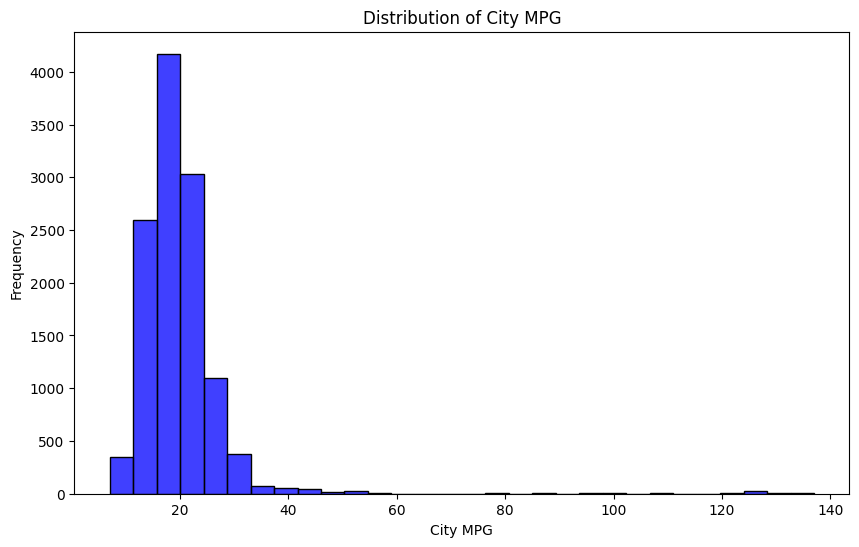

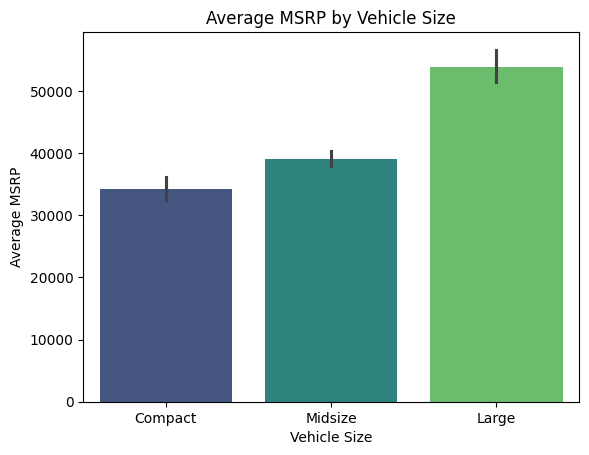

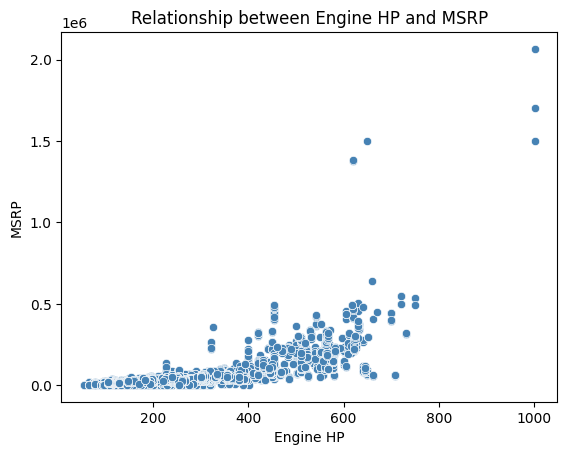

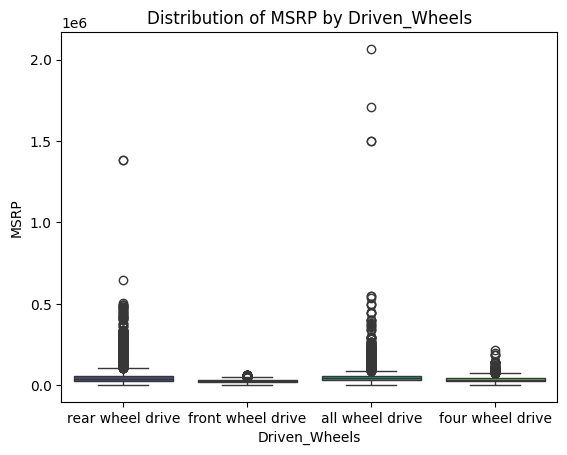

In [9]:
import matplotlib.pyplot as plt
import seaborn as sns

# Create a histogram of city mpg
plt.figure(figsize=(10, 6))
sns.histplot(df['city mpg'], bins=30, color='blue', edgecolor='black')
plt.title('Distribution of City MPG')
plt.xlabel('City MPG')
plt.ylabel('Frequency')
plt.show()

# Create a bar chart of average MSRP by Vehicle Size
fig, ax = plt.subplots()
sns.barplot(x='Vehicle Size', y='MSRP', hue='Vehicle Size', data=df, palette='viridis', legend=False)
ax.set_title('Average MSRP by Vehicle Size')
ax.set_xlabel('Vehicle Size')
ax.set_ylabel('Average MSRP')
plt.show()

# Create a scatter plot of Engine HP vs. MSRP
fig, ax = plt.subplots()
sns.scatterplot(x='Engine HP', y='MSRP', data=df, color='steelblue')
plt.title('Relationship between Engine HP and MSRP')
plt.xlabel('Engine HP')
plt.ylabel('MSRP')
plt.show()

# Create a boxplot of MSRP by Driven_Wheels
fig, ax = plt.subplots()
sns.boxplot(x='Driven_Wheels', y='MSRP', hue='Driven_Wheels', data=df, palette='viridis', legend=False)
plt.title('Distribution of MSRP by Driven_Wheels')
plt.xlabel('Driven_Wheels')
plt.ylabel('MSRP')
plt.show()

Summary of Visualizations

Histogram:
A histogram was created to visualize the distribution of the 'City MPG' column.

Bar Chart:
A bar chart was generated to show the average 'MSRP' for each category in the Vehicle Size feature.

Scatter Plot:
A scatter plot was plotted to demonstrate the relationship between 'Engine HP' and 'MSRP'.

Boxplot:
A boxplot was created to visualize the distribution of 'MSRP' for each combination in the Driven_Wheels feature.

These visualizations provide insights into different aspects of the dataset, which can be used for further analysis, trend identification, and decision-making.

Correlation Matrix:
                      Year  Engine HP  Engine Cylinders  Number of Doors  \
Year              1.000000   0.350454         -0.041405         0.263960   
Engine HP         0.350454   1.000000          0.767448        -0.103023   
Engine Cylinders -0.041405   0.767448          1.000000        -0.140019   
Number of Doors   0.263960  -0.103023         -0.140019         1.000000   
highway MPG       0.258225  -0.359533         -0.602291         0.118607   
city mpg          0.198126  -0.353997         -0.566973         0.120938   
Popularity        0.072903   0.036666          0.041167        -0.048158   
MSRP              0.227536   0.661396          0.531303        -0.126585   
Total MPG         0.234702  -0.367288         -0.601782         0.123441   
Price per HP      0.427726   0.507373          0.335130        -0.033095   

                  highway MPG  city mpg  Popularity      MSRP  Total MPG  \
Year                 0.258225  0.198126    0.072903  0.227536   0.2

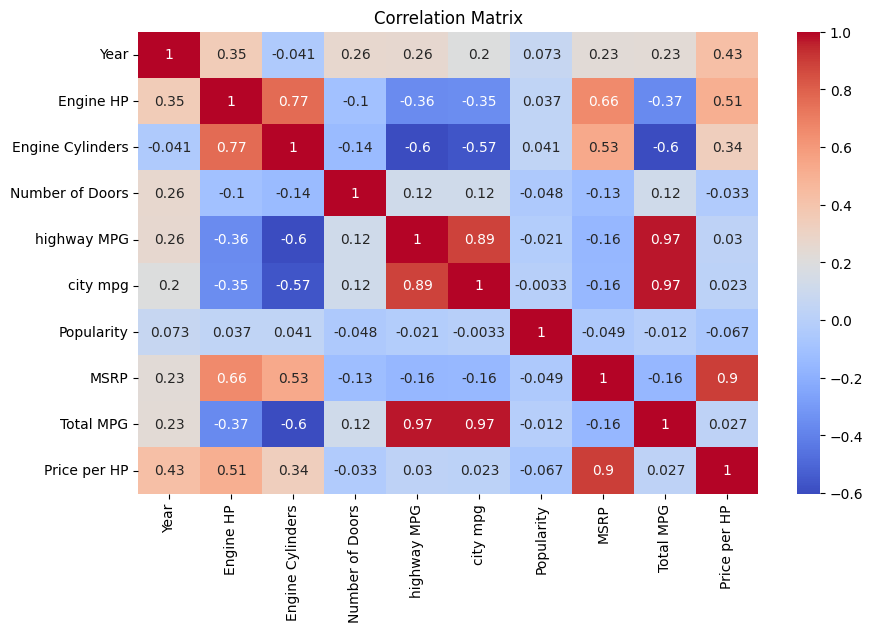

In [10]:
import seaborn as sns

# Calculate correlations among all numerical columns
correlation_matrix = df.corr(numeric_only=True)

print("Correlation Matrix:")
print(correlation_matrix)

# Create a heatmap of the correlation matrix
plt.figure(figsize=(10, 6))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm')
plt.title('Correlation Matrix')
plt.show()




Summary of Correlation Analysis

Correlation Calculation:
We calculated the correlations among all numerical columns in the dataset using df.corr().

Heatmap:
A heatmap was generated to visualize the correlation matrix.

Verification:
The correlation matrix provides a clear picture of how different variables are related to each other.

This step is crucial for understanding the relationships between the various features, which can be used for feature selection or improving the predictive power of the models.

Correlation Matrix Explanation
The correlation matrix heatmap (cell 16) visualizes Pearson correlation coefficients between all numerical columns in the dataset. Here's what it shows:

How to Read It
Values range from -1 (perfect negative correlation, dark blue) to +1 (perfect positive correlation, dark red)
0 means no linear relationship (white/light color)
The diagonal is always 1.0 (a variable perfectly correlates with itself)

Key Findings

Strong Positive Correlations (red)
Engine HP ↔ MSRP (r = 0.66): More horsepower → higher price. This is the most meaningful relationship — engine power is a strong price driver.
Engine HP ↔ Engine Cylinders (r = 0.77): More cylinders → more HP. Mechanically logical.
MSRP ↔ Price per HP (r = 0.90): This is somewhat circular — Price per HP was derived from MSRP (MSRP / Engine HP), so this high correlation is expected/artificial.
highway MPG ↔ city mpg (r = 0.89): City and highway fuel efficiency move together.
Total MPG ↔ city mpg/highway MPG (r ≈ 0.97): Again circular — Total MPG was created by adding these two columns.

Strong Negative Correlations (blue)
Engine Cylinders ↔ highway MPG (r = -0.60): More cylinders → worse fuel economy. Bigger engines are less efficient.
Engine Cylinders ↔ city mpg (r = -0.57): Same pattern for city driving.
Engine HP ↔ highway MPG (r = -0.36): More powerful engines are less fuel-efficient.

Weak/No Correlation (white)
Popularity has near-zero correlation with almost everything (r ≈ -0.07 to +0.07). Popularity appears independent of price, power, and efficiency.
Number of Doors also shows very weak correlations across the board.

Takeaway
The heatmap reveals a clear power vs. efficiency tradeoff: cars with more cylinders and horsepower cost more but get worse gas mileage. Meanwhile, Popularity is unrelated to any numeric feature, suggesting it's driven by brand perception or other non-numeric factors. Be cautious interpreting correlations involving derived columns (Total MPG, Price per HP) — they're artificially inflated by construction.

Statistical & Mathematical Foundations in This Project
1. Pearson Correlation Coefficient (Cell 16)
The most explicit statistical law applied. The .corr() method computes Pearson's r, defined as:

$$r = \frac{\sum(x_i - \bar{x})(y_i - \bar{y})}{\sqrt{\sum(x_i - \bar{x})^2 \cdot \sum(y_i - \bar{y})^2}}$$

This measures linear association between variables. Key findings from your matrix:

Engine HP ↔ MSRP: r = 0.66 (strong positive — more HP, higher price)
Engine HP ↔ Engine Cylinders: r = 0.77 (strong positive)
Engine Cylinders ↔ highway MPG: r = -0.60 (strong negative — more cylinders, less efficient)
2. Law of Large Numbers (Cells 0, 10, 12)
Justifies using sample mean/median as estimates of population parameters. When you fill missing Engine HP with the median and Engine Cylinders with the mean, you're relying on the LLN — with ~11,900 observations, these sample statistics are stable approximations of the true central tendency.

3. Central Limit Theorem (Cell 10, 14)
Underpins the use of means and standard deviations in df.describe() and groupby().mean(). The CLT guarantees that sample means are approximately normally distributed regardless of the underlying data distribution, which validates comparing group means (e.g., average MSRP by Vehicle Size).

4. Measures of Central Tendency & Dispersion (Cells 0, 10)
Mean ($\bar{x} = \frac{1}{n}\sum x_i$) — used for Engine Cylinders imputation and groupby aggregations
Median — used for Engine HP imputation (robust to outliers, which is appropriate since MSRP/HP distributions are skewed)
Standard Deviation ($\sigma = \sqrt{\frac{1}{n}\sum(x_i - \bar{x})^2}$) — reported in df.describe()
IQR (Q3 - Q1) — shown in the boxplot (Cell 14) and quartile output
5. Ratio/Proportion (Cell 8)
Price per HP = MSRP / Engine HP is a direct proportion — a fundamental arithmetic law. It assumes a linear relationship between price and power, creating a normalized comparison metric.

In short: The project's statistical backbone is Pearson correlation (measuring linear relationships), supported by LLN (justifying mean/median imputation), CLT (validating group mean comparisons), and descriptive statistics (central tendency + dispersion). The most prominent "law" on display is the Pearson correlation coefficient.